# Assignment III — Build & evaluate the IR system

**WIR 2026 · TH Köln** — extends the official `pyterrier-retrieval`
tutorial. *This notebook is the "system demo" deliverable.*

We build:

| System | What it adds | Role |
|---|---|---|
| `TF` | raw term frequency | weakest baseline |
| `TF-IDF` | + IDF | rewards rare terms |
| `BM25` | + length norm + tf saturation | **the baseline to beat** |
| `BM25-tuned` | grid-search `b`, `k1` | improvement #1 (lowest effort) |
| `BM25+RM3` | pseudo-relevance query expansion | improvement #2 |
| `BM25+PL[authors]` | informetric power-law re-rank | **our distinctive angle** |
| `BM25+PL[pubyear]*` | same boost on publication year | **negative control** |

All systems are measured with **one `pt.Experiment`** so every number is comparable,
led by **nDCG@10** (the official LongEval-Sci metric). The formal significance tests
and hypotheses live in notebook 04.

## 0. Configuration, index, topics & qrels

In [1]:
import re
from pathlib import Path
import pandas as pd
import pyterrier as pt
from ir_datasets_longeval import load

if not pt.java.started():
    pt.java.init()

CWD = Path.cwd()
REPO_ROOT     = CWD.parent if CWD.name == "notebooks" else CWD
INDEX_DIR     = REPO_ROOT / "index" / "longeval-sci"
FACET_DF_PATH = INDEX_DIR / "facet_df.json"
DATASET_ID    = "longeval-sci-2026/snapshot-1/train/dctr"

EVAL_METRICS   = ["ndcg_cut.10", "map", "recip_rank", "recall_1000"]
PRIMARY_METRIC = "ndcg_cut.10"
META_FIELDS    = {"docno": 64, "title": 256, "authors": 512, "pubyear": 8}

index = pt.IndexFactory.of(str(INDEX_DIR))
print(index.getCollectionStatistics().toString().splitlines()[0])  # doc count

Java started and loaded: pyterrier.java.colab, pyterrier.java, pyterrier.java.24, pyterrier.terrier.java [version=5.11 (build: craig.macdonald 2025-01-13 21:29), helper_version=0.0.8]


Number of documents: 869902


In [8]:
def clean_query(q: str) -> str:
    """Strip punctuation that breaks Terrier's query parser."""
    return re.sub(r"[^\w\s]", " ", q).strip()

dataset = load(DATASET_ID)
topics = pd.DataFrame([{"qid": q.query_id, "query": clean_query(q.default_text())}
                       for q in dataset.queries_iter()])
qrels = (pd.DataFrame(dataset.qrels_iter())
           .rename(columns={"query_id": "qid", "doc_id": "docno", "relevance": "label"})
           [["qid", "docno", "label"]])
print(f"{len(topics)} topics, {len(qrels)} qrels")
topics.head(3)

100 topics, 8772 qrels


,qid,query
0,d40a44b633a216fc65484a60dadd48ac,utilizing llm to identify entities in natural ...
1,1200cc678dce697633576f9941994baa,psychology human behavior
2,e54f68f74633d43b86d0247af6197544,mark twain


In [12]:
topics["query"].shape

(100,)

## 1. The baseline ladder — TF → TF-IDF → BM25

These are the systems we **must** beat. The expected ordering itself is a result:
`BM25 > TF-IDF > TF`, because BM25 adds **document-length normalisation** and **tf
saturation** on top of IDF (WIR-02). `% 1000` caps each retriever at 1000 results
per query — enough for recall@1000 and fast enough to re-rank later.

In [13]:
tf    = pt.terrier.Retriever(index, wmodel="Tf")     % 1000   
tfidf = pt.terrier.Retriever(index, wmodel="TF_IDF") % 1000
bm25  = pt.terrier.Retriever(index, wmodel="BM25")   % 1000
baselines = {"TF": tf, "TF-IDF": tfidf, "BM25": bm25}

## 2. Improvement #1 — tuned BM25 (`b`, `k1` grid search)

BM25 has two knobs: `b` (how strongly to penalise long documents) and `k1` (how fast
term frequency saturates). We grid-search them to maximise nDCG@10. The `b`/`k1`
controls must be **pre-registered** at construction, and `GridSearch` must address the
raw `Retriever` (we add the `% 1000` cutoff to the winner afterwards).

> For a clean report we should tune on a held-out split; here we tune on the same
> training topics for simplicity — fine because it competes against the same BM25.

In [14]:
bm25_raw = pt.terrier.Retriever(index, wmodel="BM25",controls={"bm25.b": 0.75, "bm25.k_1": 1.2})
try:
    bm25_tuned = pt.GridSearch(
        bm25_raw,
        {bm25_raw: {"bm25.b":   [0.4, 0.6, 0.75, 0.9],
                    "bm25.k_1": [0.9, 1.2, 1.6, 2.0]}},
        topics, qrels, PRIMARY_METRIC, verbose=False,
    ) % 1000
    print("grid search complete")
except Exception as exc:
    print(f"GridSearch failed ({exc}); falling back to default BM25.")
    bm25_tuned = bm25

Best ndcg_cut.10 is 0.305042
Best setting is ['TerrierRetr(BM25) bm25.b=0.9', 'TerrierRetr(BM25) bm25.k_1=1.2']
grid search complete


## 3. Improvement #2 — BM25 + RM3 (pseudo-relevance feedback)

RM3 retrieves with BM25, expands the query with the most informative terms from the
top-ranked documents, and retrieves again. Query expansion was a reliable gain for
LongEval 2025 systems on this scientific collection.

In [15]:
bm25_rm3 = bm25 >> pt.rewrite.RM3(index) >> bm25

## 4. Our distinctive angle to cover — the informetric power-law boost

We can re-ranking a text score with a power-law
metadata field. We implement it as an **EF × IDF** boost applied after BM25:

- **EF** (*element frequency*): how often a facet value (an author) appears among the
  documents retrieved **for this query** — a signal of what the query is "about" in
  author space.
- **IDF** (across the whole collection, from `facet_df.json`): a *rare* author is more
  informative than a prolific one.

$$\text{final} = \text{norm}(\text{bm25}) + \lambda\cdot\text{norm}(\text{EF}\times\text{IDF})$$

We instantiate it twice: on **`authors`** (expected to help) and on **`pubyear`** as a
**negative control** (We have learnt that boosting by year hurts).

In [16]:
import json, math
from collections import defaultdict

def load_facet_df(path=FACET_DF_PATH):
    data = json.loads(Path(path).read_text())
    return data, data.pop("_n_docs")

def split_facet(raw: str):
    """Stored authors are a '; '-joined string (names contain commas) -> split on ';'."""
    return [p.strip().lower() for p in str(raw).split(";") if p and p.strip()] if raw else []

def make_powerlaw_booster(field, facet_df, n_docs, lam=0.3, agg="sum"):
    field_df = facet_df.get(field, {})
    def idf(v):
        return math.log((n_docs + 1) / (field_df.get(v, 0) + 1))  # +1 smoothing
    def minmax(xs):
        lo, hi = min(xs), max(xs); rng = hi - lo
        return [(x - lo) / rng if rng > 0 else 0.0 for x in xs]
    def rerank(res):
        if res.empty or field not in res.columns:
            return res
        res = res.copy()
        ef = defaultdict(int); doc_vals = []
        for raw in res[field].tolist():
            vals = split_facet(raw); doc_vals.append(vals)
            for v in set(vals):
                ef[v] += 1
        boosts = [ (max if agg == "max" else sum)(ef[v] * idf(v) for v in set(vals)) if vals else 0.0
                   for vals in doc_vals ]
        res["score"] = [s + lam * b for s, b in zip(minmax(res["score"].tolist()), minmax(boosts))]
        return pt.model.add_ranks(res.sort_values("score", ascending=False))
    return pt.apply.by_query(rerank, add_ranks=False)

facet_df, n_docs = load_facet_df()
# BM25 that also RETURNS the facet columns so the booster can read them
meta_cols = [c for c in ("docno", "authors", "pubyear") if c in META_FIELDS]
bm25_meta = pt.terrier.Retriever(index, wmodel="BM25", metadata=meta_cols) % 1000

bm25_pl_authors = bm25_meta >> make_powerlaw_booster("authors", facet_df, n_docs, lam=0.3)
bm25_pl_pubyear = bm25_meta >> make_powerlaw_booster("pubyear", facet_df, n_docs, lam=0.3)
print("power-law re-rankers built (authors + pubyear control)")

power-law re-rankers built (authors + pubyear control)


## 5. The metrics table — the core result

One experiment, every system, led by nDCG@10 (sorted descending). This is the table
our Stage-3 report is built around.

In [18]:
systems = [tf, tfidf, bm25, bm25_tuned, bm25_rm3, bm25_pl_authors, bm25_pl_pubyear]
retriever   = ["TF", "TF-IDF", "BM25", "BM25-tuned", "BM25+RM3",
           "BM25+PL[authors]", "BM25+PL[pubyear]*"]

table = pt.Experiment(systems, topics, qrels, eval_metrics=EVAL_METRICS, names=retriever)
table = table.sort_values(PRIMARY_METRIC, ascending=False).reset_index(drop=True)
table.round(4)

,name,map,recip_rank,recall_1000,ndcg_cut.10
0,BM25-tuned,0.2641,0.4728,0.8598,0.3050
1,BM25,0.2573,0.4717,0.8581,0.2922
2,TF-IDF,0.2592,0.4786,0.8575,0.2921
3,BM25+PL[authors],0.2529,0.4676,0.8581,0.2885
4,BM25+RM3,0.2402,0.4644,0.8701,0.2781
5,BM25+PL[pubyear]*,0.1734,0.3394,0.8581,0.2015
6,TF,0.0379,0.0924,0.6113,0.0470


## 6. Visualise nDCG@10 by system

A quick bar chart makes the ranking of systems obvious at a glance.

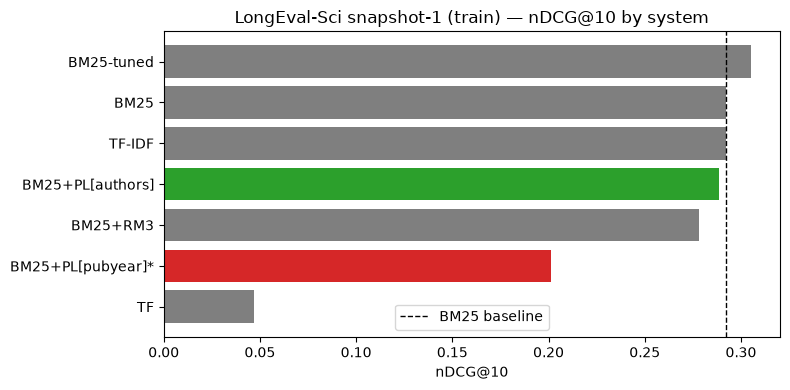

In [19]:
import matplotlib.pyplot as plt

ordered = table.sort_values(PRIMARY_METRIC)
colors = ["tab:green" if "authors" in n else "tab:red" if "pubyear" in n
          else "tab:gray" for n in ordered["name"]]
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(ordered["name"], ordered[PRIMARY_METRIC], color=colors)
ax.axvline(table.loc[table["name"] == "BM25", PRIMARY_METRIC].iloc[0],
           ls="--", c="black", lw=1, label="BM25 baseline")
ax.set_xlabel("nDCG@10"); ax.set_title("LongEval-Sci snapshot-1 (train) — nDCG@10 by system")
ax.legend(); plt.tight_layout(); plt.show()

> **Remarks:** BM25 should beat TF-IDF should beat TF (length
> normalisation). The author power-law boost is our contribution; pubyear is the
> control we expect to *not* help. Whether those expectations hold **significantly**
> is exactly what **`04_hypotheses_and_error_analysis`** tests.